<a href="https://colab.research.google.com/github/Ashutosh-Mi/GENAI_ML_CAPSTONE/blob/main/Sales%20Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_restaurants = pd.read_csv("/content/sample_data/resturants.csv")
df_restaurants.head()

,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe


In [3]:
df_items = pd.read_csv("/content/sample_data/items.csv")
df_items.head()

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


In [4]:
df_sales = pd.read_csv("/content/sample_data/sales.csv", date_format='%Y-%m-%d')
df_sales["date"] = pd.to_datetime(df_sales["date"])
df_sales.head()

,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


In [5]:
from scipy.stats import zscore
import numpy as np
def get_outliers(df, col):
  z_col = zscore(df[col])
  threshold = 2
  outlier = np.where(z_col - threshold > 0, True, np.where(z_col + threshold < 0, True, False))
  return df[outlier == True].index.tolist()
def remove_outliers(df, cols):
  outliers = []
  for col in cols:
    outliers.extend(get_outliers(df, col))
  return df.drop(index=outliers, axis=0)

In [6]:
df_items2 = remove_outliers(df_items, ["kcal", "cost"])
df_sales["date_int"] = df_sales["date"].dt.strftime('%Y%m%d').astype(int)
df_sales2 = remove_outliers(df_sales, ["date_int", "price", "item_count"])

In [7]:
def factorize(df, cols):
  for col in cols:
      codes, _ = pd.factorize(df[col])
      df[f"{col}_F"] = codes

In [8]:
factorize(df_items2, ["name"])
factorize(df_restaurants, ["name"])

In [9]:
df_all = pd.merge(df_sales2, df_items2, left_on="item_id", right_on="id", left_index=False, right_index=False)
df_all.drop(columns=["id"], inplace=True)
df_all.rename(columns={"name": "item_name", "name_F": "item_name_F"}, inplace=True)
df_all = pd.merge(df_all, df_restaurants, left_on="store_id", right_on="id", left_index=False, right_index=False)
df_all.drop(columns=["id"], inplace=True)
df_all.rename(columns={"name": "store_name", "name_F": "store_name_F"}, inplace=True)
df_all = df_all[["date", "date_int", "item_id", "price", "item_count", "item_name", "item_name_F", "kcal", "store_id", "store_name", "store_name_F"]]
df_all = df_all[df_all["item_count"] > 0.0]
df_all


,date,date_int,item_id,price,item_count,item_name,item_name_F,kcal,store_id,store_name,store_name_F
0,2019-01-01,20190101,3,29.22,2.0,Sweet Fruity Cake,2,931,1,Bob's Diner,0
1,2019-01-01,20190101,4,26.42,22.0,Amazing Steak Dinner with Rolls,3,763,1,Bob's Diner,0
2,2019-01-01,20190101,12,4.87,7.0,Fantastic Sweet Cola,11,478,1,Bob's Diner,0
3,2019-01-01,20190101,13,4.18,12.0,Sweet Frozen Soft Drink,12,490,1,Bob's Diner,0
4,2019-01-01,20190101,21,23.23,13.0,Amazing Fish with Vegetables Meal,20,269,1,Bob's Diner,0
...,...,...,...,...,...,...,...,...,...,...,...
102354,2021-12-31,20211231,59,23.37,54.0,Blue Ribbon Beef Entree,56,392,1,Bob's Diner,0
102355,2021-12-31,20211231,67,7.00,6.0,Sweet Lamb Cake,64,558,1,Bob's Diner,0
102356,2021-12-31,20211231,68,8.70,1.0,Blue Ribbon Fruity Milky Cake,65,652,1,Bob's Diner,0
102357,2021-12-31,20211231,73,5.16,10.0,Milky Cake,39,596,1,Bob's Diner,0


Distribution of Features


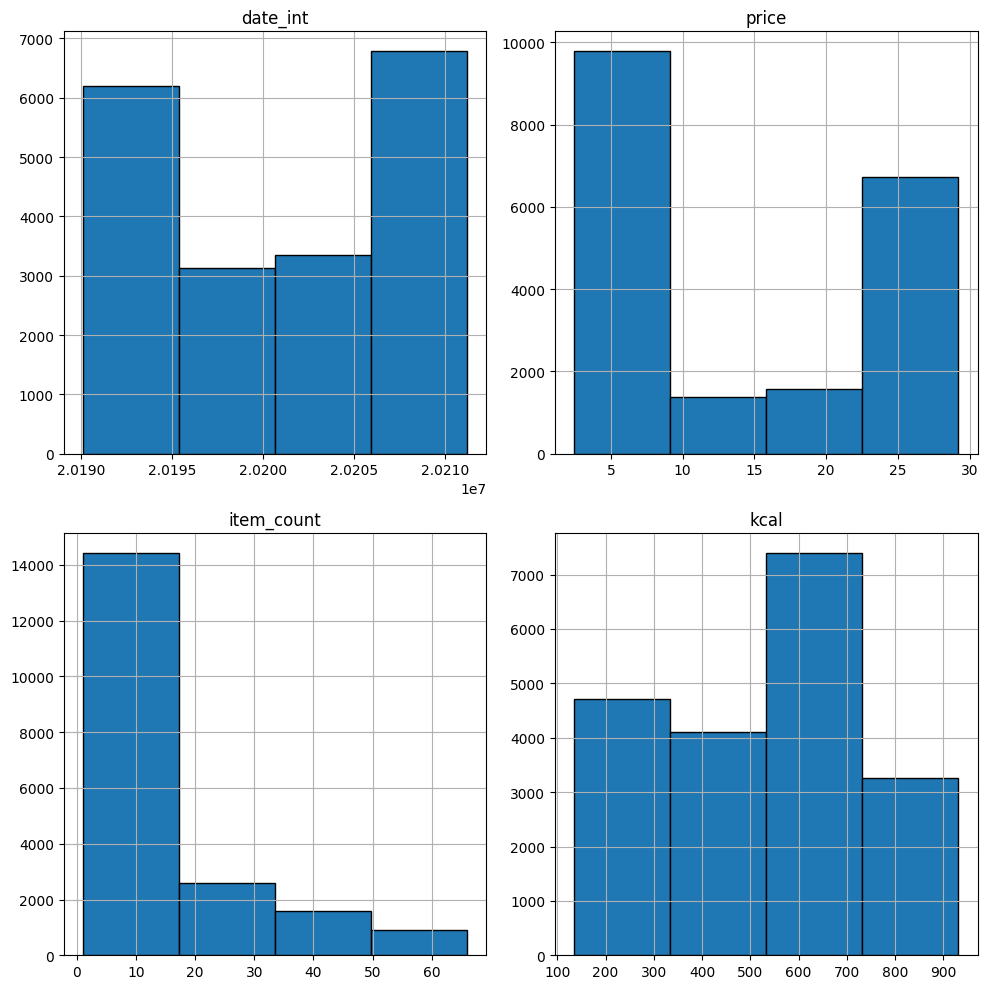

In [10]:
df_features = df_all[["date_int", "price", "item_count", "kcal"]]
df_features.hist(bins=4, figsize=(10, 10), edgecolor='black')
plt.tight_layout()
print("Distribution of Features")
plt.show()

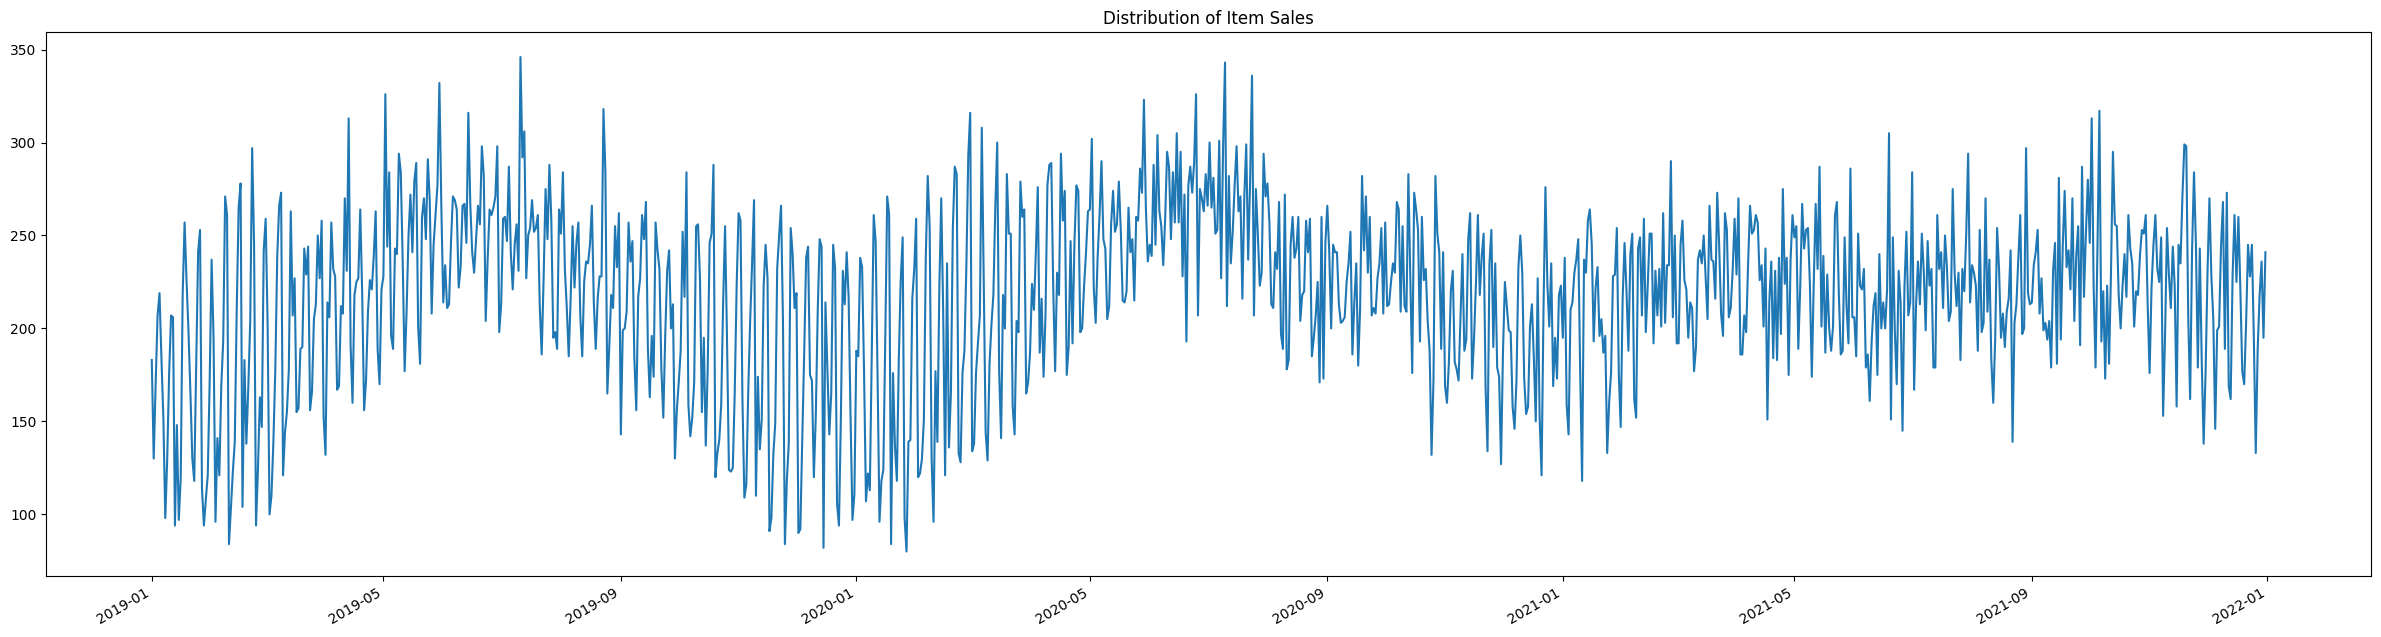

In [11]:
df_item_sales = df_all[["date", "item_count"]].groupby(by=["date"]).sum().reset_index()
fig, ax = plt.subplots(figsize=(30, 8))
ax.plot(df_item_sales["date"], df_item_sales["item_count"])
ax.xaxis_date()
fig.autofmt_xdate()
ax.set_title("Distribution of Item Sales")
plt.show()

In [12]:
df_item_sales

,date,item_count
0,2019-01-01,183.0
1,2019-01-02,130.0
2,2019-01-03,170.0
3,2019-01-04,207.0
4,2019-01-05,219.0
...,...,...
1091,2021-12-27,189.0
1092,2021-12-28,218.0
1093,2021-12-29,236.0
1094,2021-12-30,195.0


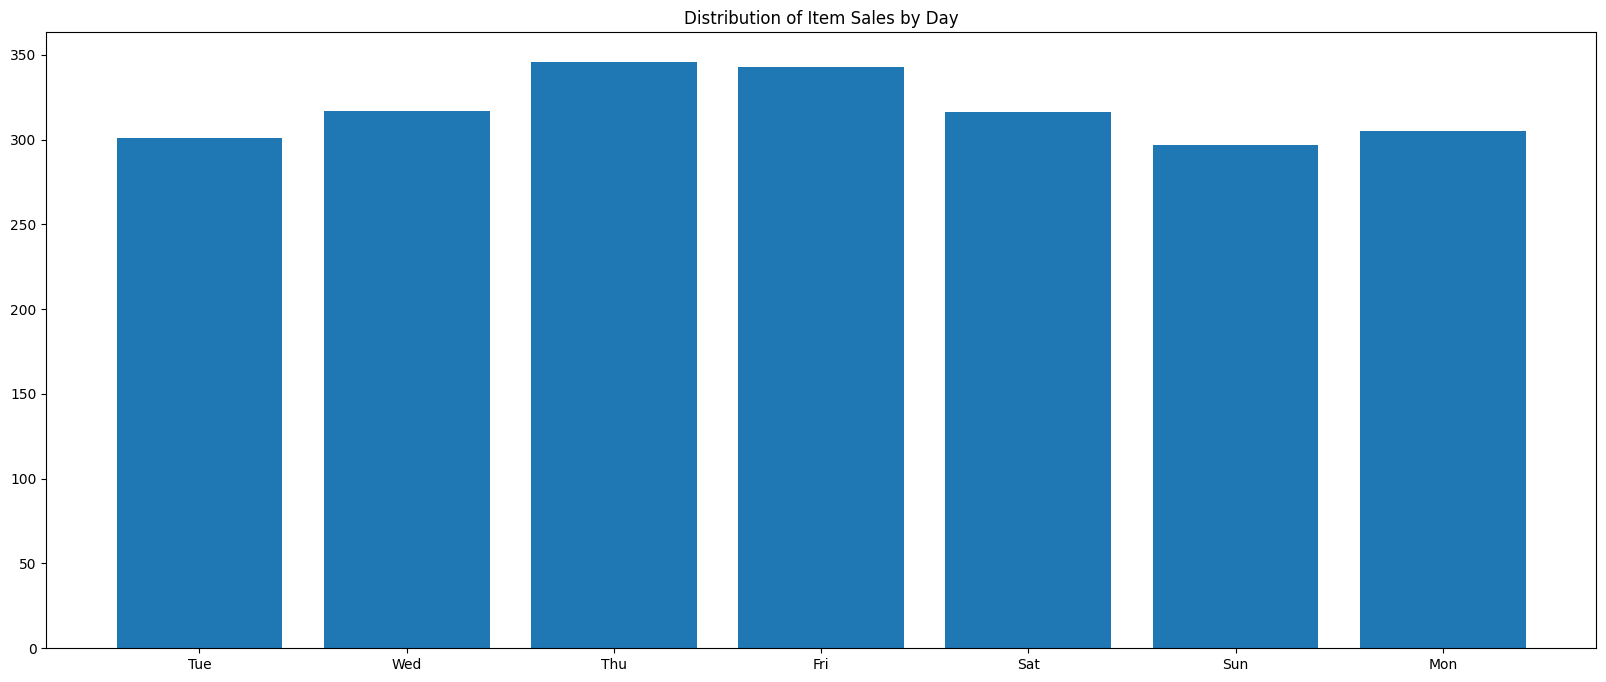

In [13]:
df_item_sales["day"] = df_item_sales["date"].dt.strftime("%a")
fig, ax = plt.subplots(figsize=(20, 8))
ax.bar(df_item_sales["day"], df_item_sales["item_count"])
ax.set_title("Distribution of Item Sales by Day")
plt.show()


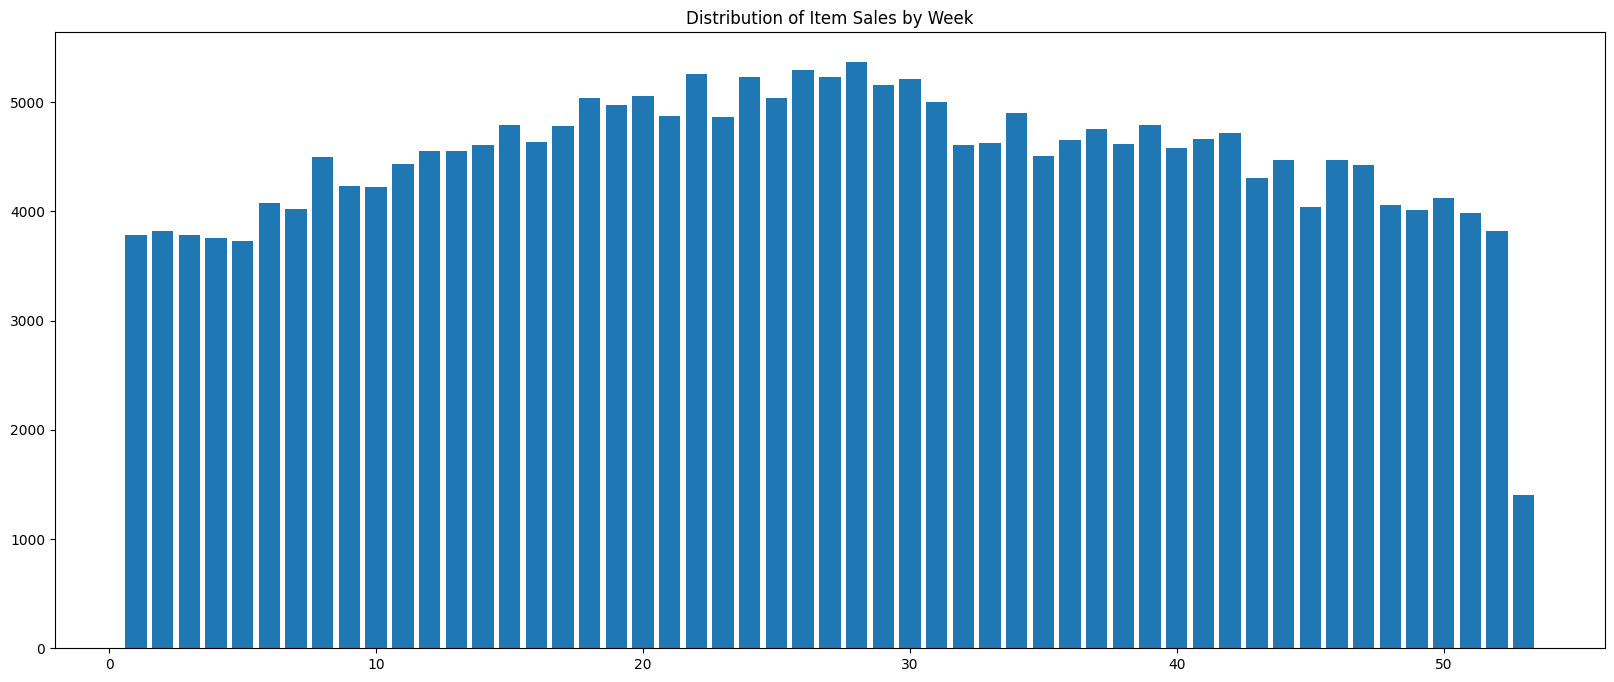

In [14]:
df_item_sales["week"] = df_item_sales["date"].dt.isocalendar().week
df_item_sales_by_week = df_item_sales[["week", "item_count"]].groupby(by=["week"]).sum().reset_index()
fig, ax = plt.subplots(figsize=(20, 8))
ax.bar(df_item_sales_by_week["week"], df_item_sales_by_week["item_count"])
ax.set_title("Distribution of Item Sales by Week")
plt.show()

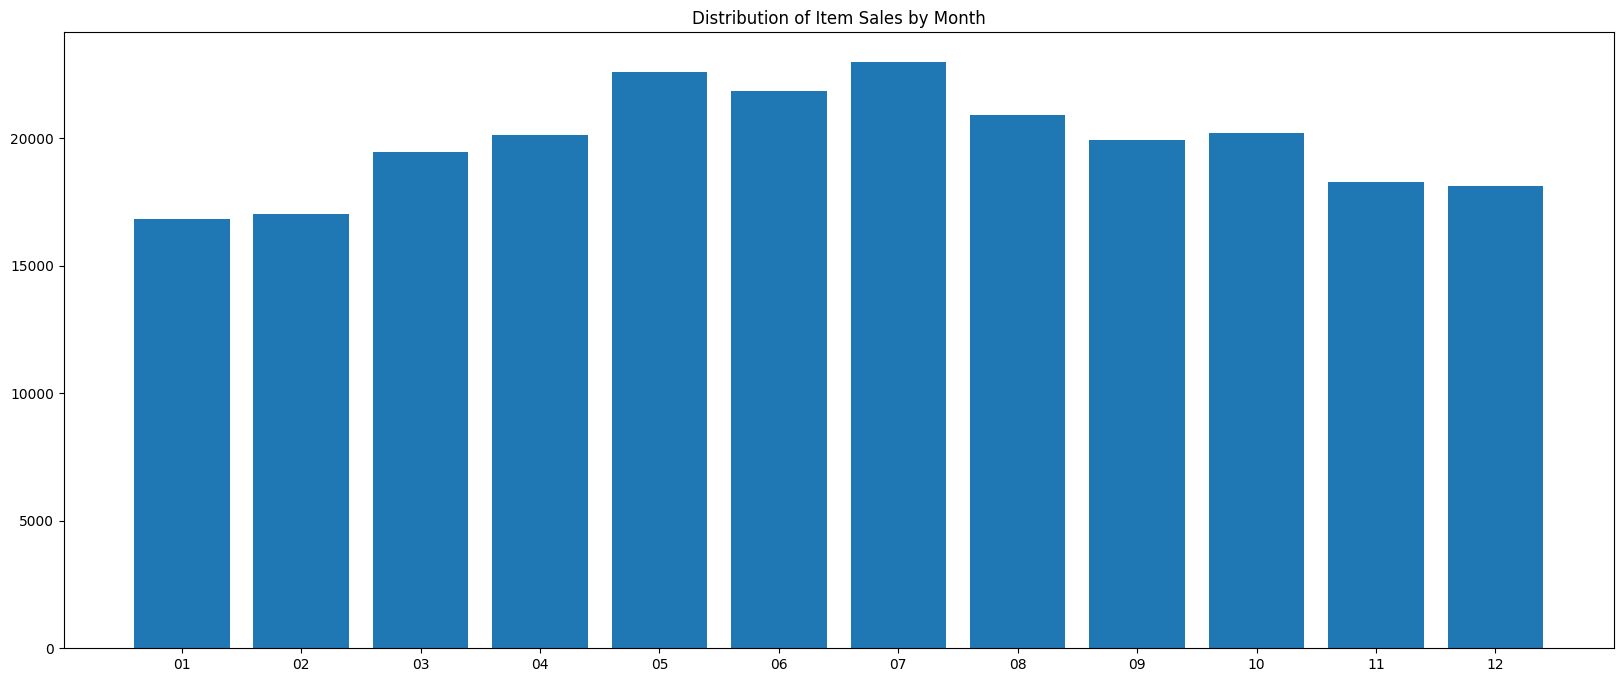

In [15]:
df_item_sales["month"] = df_item_sales["date"].dt.strftime("%m")
df_item_sales_by_month = df_item_sales[["month", "item_count"]].groupby(by=["month"]).sum().reset_index()
fig, ax = plt.subplots(figsize=(20, 8))
ax.bar(df_item_sales_by_month["month"], df_item_sales_by_month["item_count"])
ax.set_title("Distribution of Item Sales by Month")
plt.show()

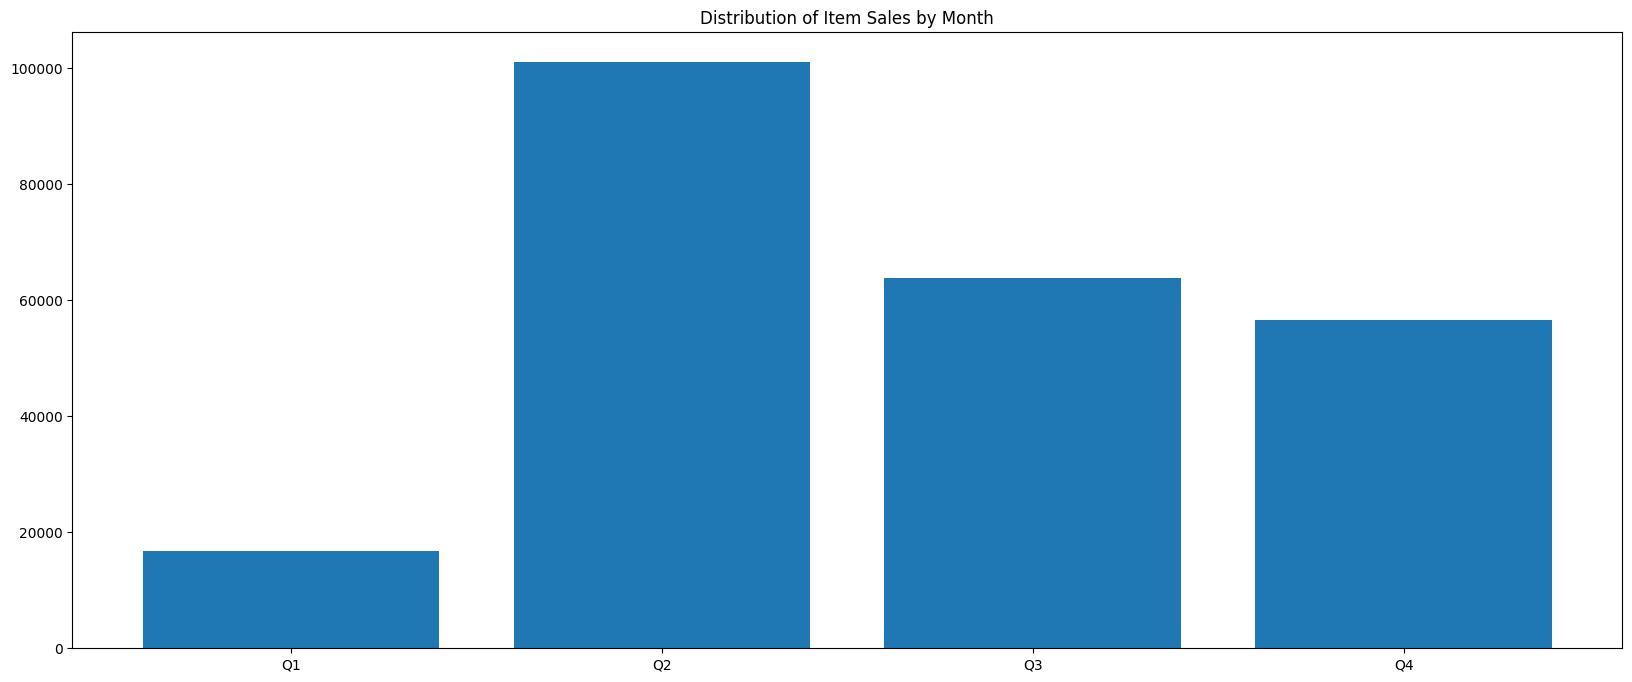

In [16]:
df_item_sales["quarter"] = (df_item_sales["month"].astype(int) / 4 + 1).round().map('Q{:,.0f}'.format)
df_item_sales_by_quarter = df_item_sales[["quarter", "item_count"]].groupby(by=["quarter"]).sum().reset_index()
fig, ax = plt.subplots(figsize=(20, 8))
ax.bar(df_item_sales_by_quarter["quarter"], df_item_sales_by_quarter["item_count"])
ax.set_title("Distribution of Item Sales by Month")
plt.show()

In [17]:
df_store_sales = df_all[["store_name", "date", "item_count"]].groupby(by=["store_name", "date"]).sum().reset_index()
df_store_sales["year"] = df_store_sales["date"].dt.strftime("%Y")
df_store_sales["month"] = df_store_sales["date"].dt.strftime("%m")
df_store_sales["day"] = df_store_sales["date"].dt.strftime("%a")
df_store_sales_by_year = df_store_sales[["store_name", "year", "item_count"]].groupby(by=["store_name", "year"]).sum().reset_index()
df_store_sales_by_month = df_store_sales[["store_name", "month", "item_count"]].groupby(by=["store_name", "month"]).sum().reset_index()
df_store_sales_by_day = df_store_sales[["store_name", "day", "item_count"]].groupby(by=["store_name", "day"]).sum().reset_index()

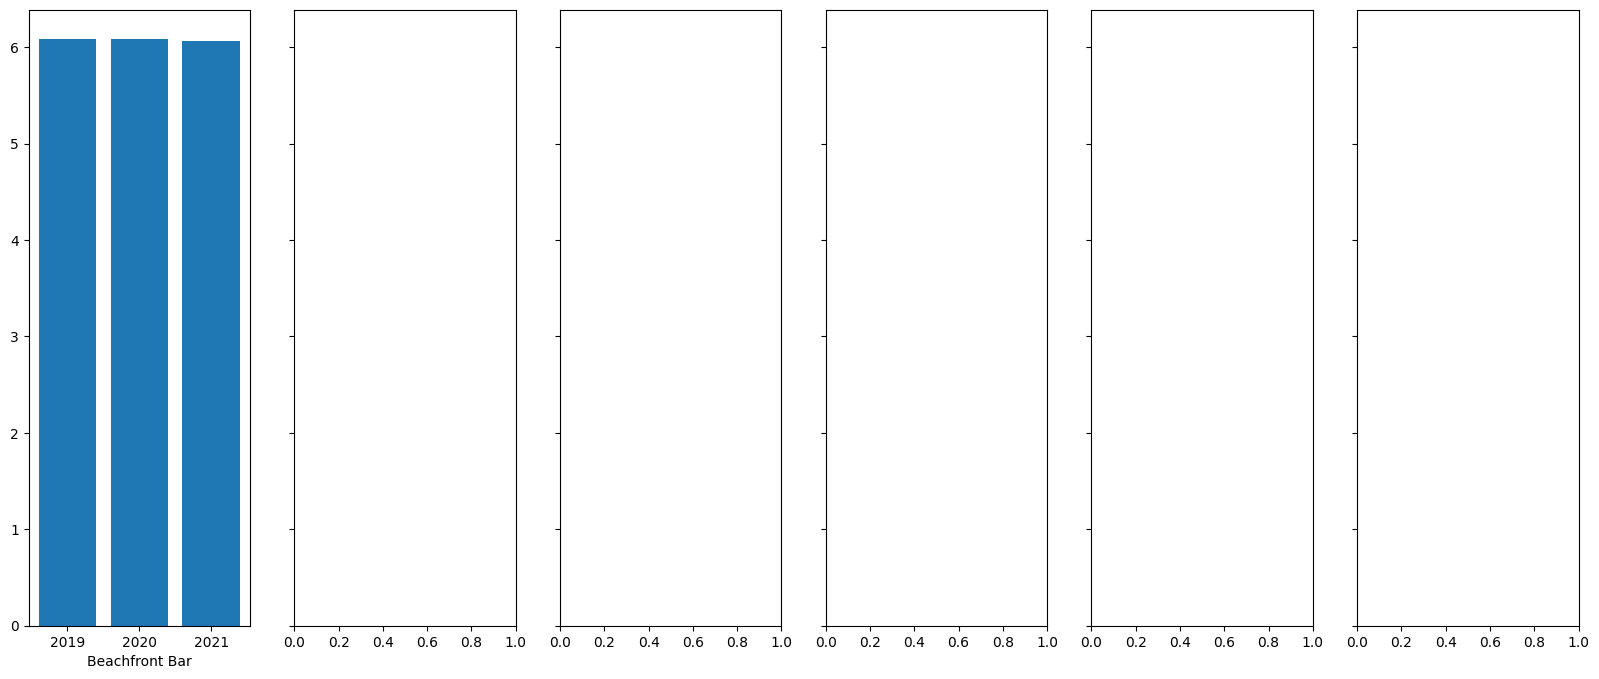

In [18]:
import math
store_names = df_store_sales_by_year["store_name"].unique()
fig, axs = plt.subplots(1, len(store_names), sharey=True, figsize=(20,8))
for ax, store_name in zip(axs, store_names):
  df = df_store_sales_by_year[df_store_sales_by_year["store_name"] == store_name]
  ax.bar(df["year"], df["item_count"].map(math.log))
  ax.set_xlabel(store_name)
  plt.show()
ax.set_title("Distribution of Store Sales by Year")
fig.subplots_adjust(wspace=0)

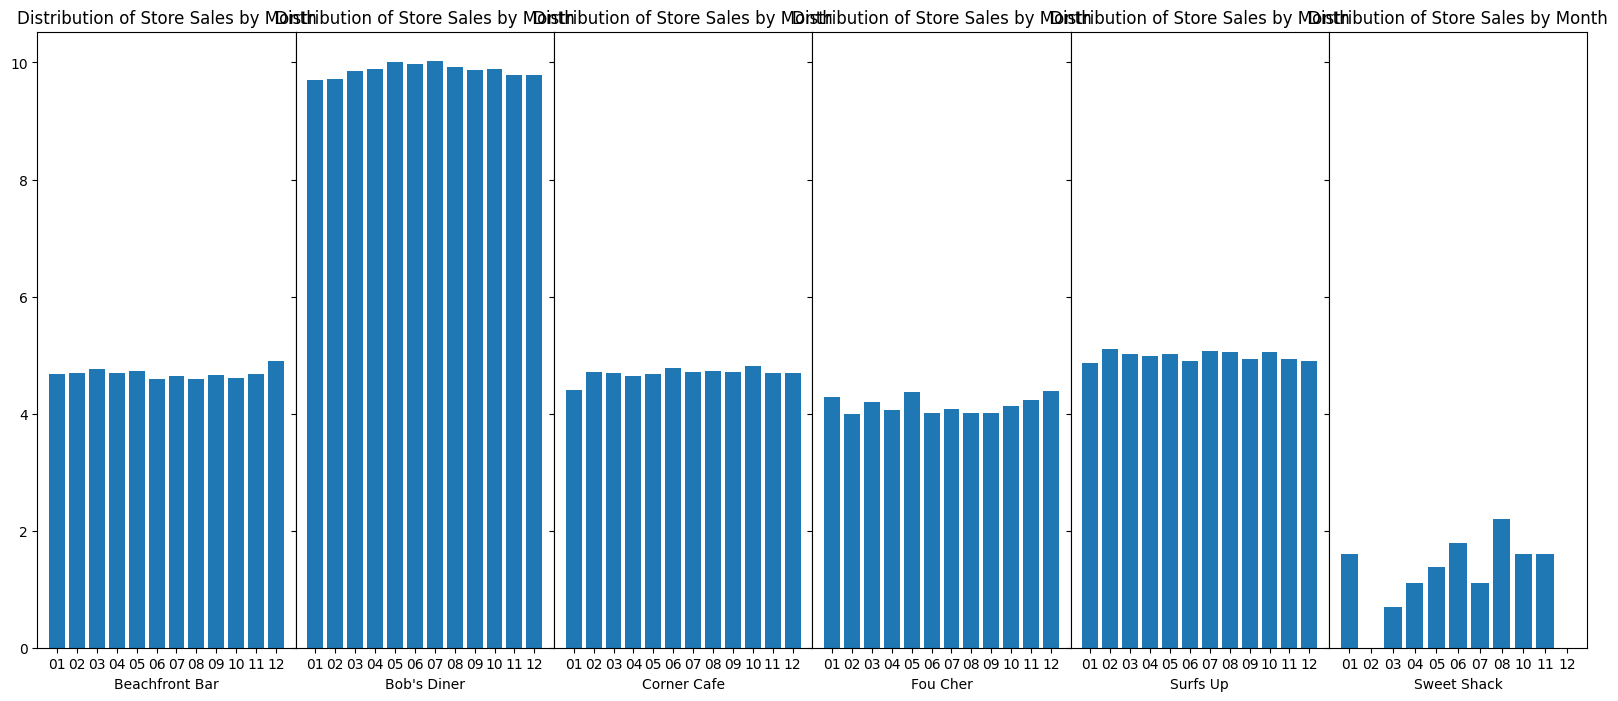

In [19]:
import math
store_names = df_store_sales_by_month["store_name"].unique()
fig, axs = plt.subplots(1, len(store_names), sharey=True, figsize=(20,8))
for ax, store_name in zip(axs, store_names):
  df = df_store_sales_by_month[df_store_sales_by_month["store_name"] == store_name]
  ax.bar(df["month"], df["item_count"].map(math.log))
  ax.set_xlabel(store_name)
  ax.set_title("Distribution of Store Sales by Month")
fig.subplots_adjust(wspace=0)
plt.show()

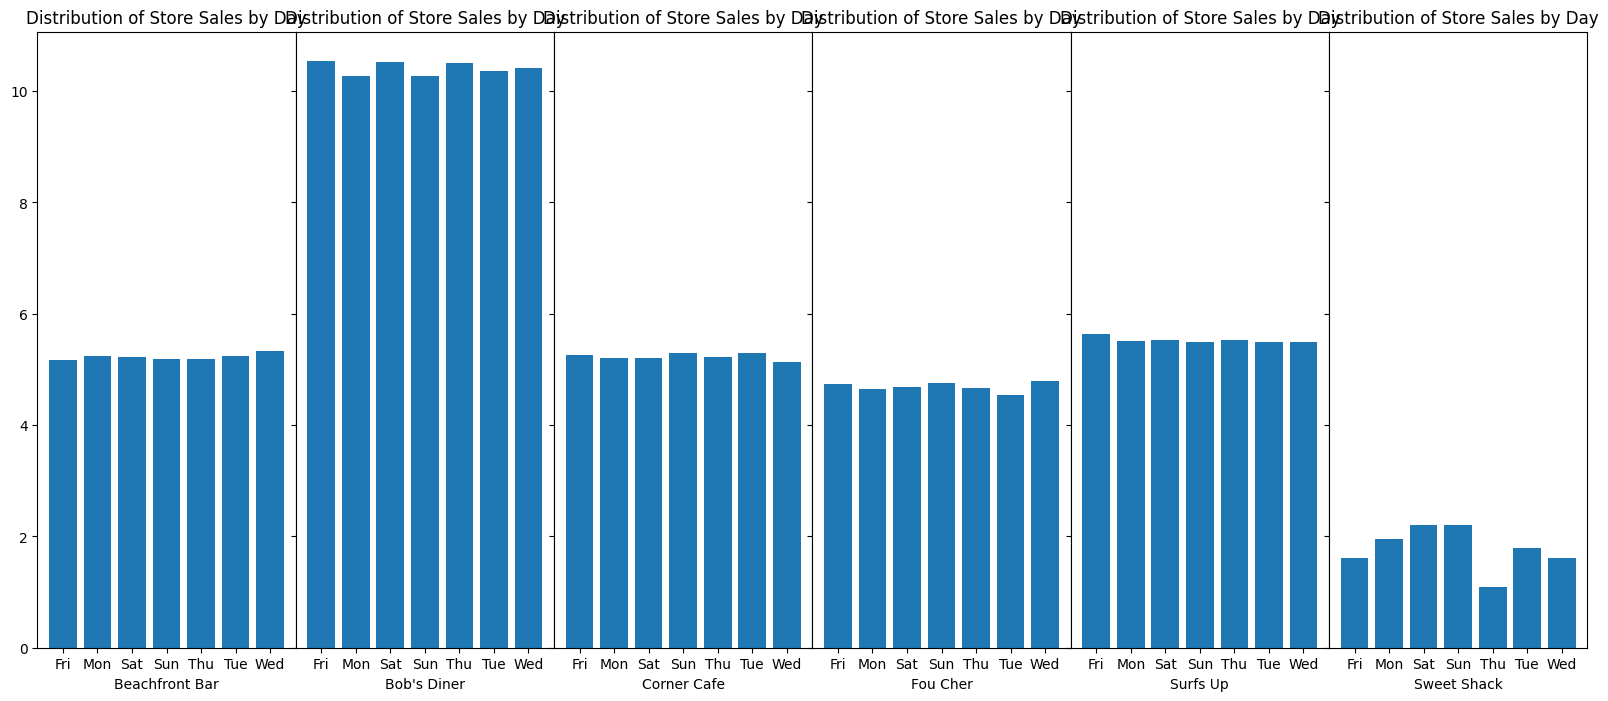

In [20]:
import math
store_names = df_store_sales_by_day["store_name"].unique()
fig, axs = plt.subplots(1, len(store_names), sharey=True, figsize=(20,8))
for ax, store_name in zip(axs, store_names):
  df = df_store_sales_by_day[df_store_sales_by_day["store_name"] == store_name]
  ax.bar(df["day"], df["item_count"].map(math.log))
  ax.set_xlabel(store_name)
  ax.set_title("Distribution of Store Sales by Day")
fig.subplots_adjust(wspace=0)
plt.show()

In [21]:
df_pop_sales = df_all[["store_name", "item_name", "item_count"]].groupby(by=["store_name", "item_name"]).sum().reset_index()
df_popitem_sales = df_pop_sales[["item_name", "item_count"]].groupby(by=["item_name"]).sum().sort_values("item_count", ascending=False).reset_index()

/tmp/ipykernel_2965/3452112605.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha="right", va="center_baseline")


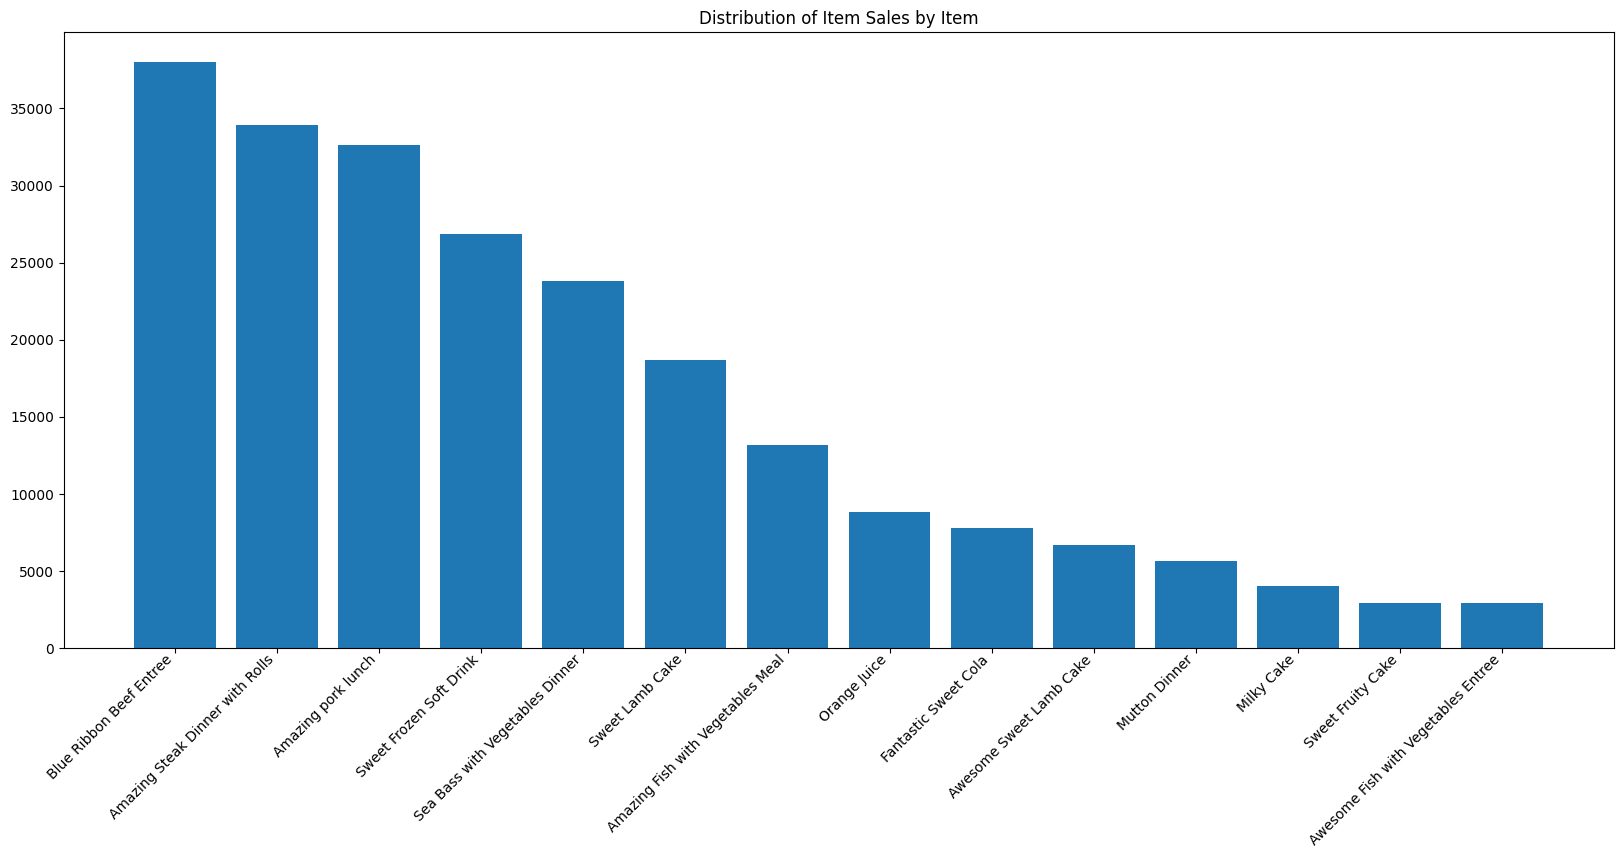

In [22]:
fig, ax = plt.subplots(figsize=(20, 8))
df = df_popitem_sales[df_popitem_sales["item_count"] > 2000]
ax.bar(df["item_name"], df["item_count"])
ax.set_title("Distribution of Item Sales by Item")
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha="right", va="center_baseline")
plt.show()

In [23]:
df_top10_items = df_popitem_sales[df_popitem_sales["item_count"] > 2000].iloc[:10,:]
df_top10_items

,item_name,item_count
0,Blue Ribbon Beef Entree,38034.0
1,Amazing Steak Dinner with Rolls,33940.0
2,Amazing pork lunch,32631.0
3,Sweet Frozen Soft Drink,26860.0
4,Sea Bass with Vegetables Dinner,23839.0
5,Sweet Lamb Cake,18696.0
6,Amazing Fish with Vegetables Meal,13190.0
7,Orange Juice,8835.0
8,Fantastic Sweet Cola,7791.0
9,Awesome Sweet Lamb Cake,6674.0


In [24]:
df_store_items = df_all[["store_name", "item_name"]]
df_store_items[df_store_items["item_name"].isin(df_top10_items["item_name"])]["store_name"].unique()

array(["Bob's Diner"], dtype=object)

In [25]:
df_all[["store_name", "item_count"]].groupby(["store_name"]).sum().sort_values(by="item_count", ascending=False).reset_index()

,store_name,item_count
0,Bob's Diner,233248.0
1,Surfs Up,1762.0
2,Corner Cafe,1310.0
3,Beachfront Bar,1305.0
4,Fou Cher,766.0
5,Sweet Shack,44.0


In [26]:
df_all["sale_amount"] = df_all["item_count"] * df_all["price"]
df = df_all[["store_name", "date"]].groupby(["store_name", "date"]).count().reset_index()
df_days = df.groupby(["store_name"]).count().rename({"date": "days"}, axis=1).reset_index()
df_sale_amount = df_all[["store_name", "sale_amount"]].groupby(["store_name"]).sum().reset_index()

In [27]:
df_sales_days = pd.merge(df_sale_amount, df_days, on=['store_name'])
df_sales_days["sales_per_day"] = df_sales_days["sale_amount"] / df_sales_days["days"]
df_sales_days.sort_values(by="sales_per_day", ascending=False)

,store_name,sale_amount,days,sales_per_day
1,Bob's Diner,4045933.15,1096,3691.544845
2,Corner Cafe,16551.43,783,21.138480
3,Fou Cher,10999.65,590,18.643475
4,Surfs Up,14798.69,893,16.571881
5,Sweet Shack,226.39,44,5.145227
0,Beachfront Bar,3796.20,806,4.709926


In [28]:
df_costly_items = df_all[["store_name", "item_name", "price", "kcal"]].groupby(["store_name", "item_name"]).max().sort_values(by=["store_name","price"], ascending=False)
df_costly_items.loc

In [29]:
for store_name in df_costly_items.index.get_level_values(0).unique():
  print(df_costly_items.loc[[store_name]].iloc[0])

price      6.89
kcal     612.00
Name: (Sweet Shack, Blue Ribbon Milky Cake), dtype: float64
price     26.21
kcal     607.00
Name: (Surfs Up, Steak Meal), dtype: float64
price     28.65
kcal     744.00
Name: (Fou Cher, Original Fruity Cod with Bread and Vegetables Entree), dtype: float64
price     26.37
kcal     653.00
Name: (Corner Cafe, Pike Lunch), dtype: float64
price     29.22
kcal     931.00
Name: (Bob's Diner, Sweet Fruity Cake), dtype: float64
price      5.7
kcal     538.0
Name: (Beachfront Bar, Sweet Vegi Soft Drink), dtype: float64


# Machine learning
###### Build and compare linear regression, random forest, and XGBoost models for predictions

<Axes: ylabel='price'>

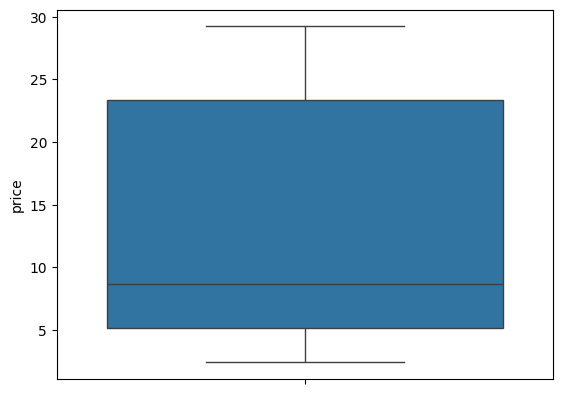

In [30]:
import seaborn as sns
sns.boxplot(df_all['price'])

In [31]:
df_all["day"] = df_all["date"].dt.strftime("%w").astype(int)
df_all["week"] = df_all["date"].dt.isocalendar().week
df_all["month"] = df_all["date"].dt.strftime("%m").astype(int)
df_all["year"] = df_all["date"].dt.strftime("%Y").astype(int)
df_all["quarter"] = (df_all["month"].astype(int) / 4 + 1).round().astype(int)

In [32]:
train = df_all[df_all["date"] <= '2021-06-30']
test = df_all[df_all["date"] > '2021-06-30']
X_train = train.drop('item_count', axis=1)[["date_int", "item_id", "price", "kcal", "store_id"]]
X_test = test.drop('item_count', axis=1)[["date_int", "item_id", "price", "kcal", "store_id"]]
y_train = train["item_count"]
y_test = test["item_count"]

### Linear Regression

In [33]:
import statsmodels.formula.api as sm
model = sm.ols(formula="item_count ~ date_int + item_id + price + kcal + store_id", data=train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             item_count   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     706.7
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:02:26   Log-Likelihood:                -65144.
No. Observations:               16028   AIC:                         1.303e+05
Df Residuals:                   16022   BIC:                         1.303e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -36.6836    303.454     -0.121      0.9

In [34]:
def calculate_residuals(model, features, label):
  predictions =  model.predict(features)
  df_results = pd.DataFrame({'Actual' : label, 'Predicted' : predictions})
  df_results['Residuals'] = abs(df_results['Actual']) - abs(df_results['Predicted'])
  return df_results
def linear_assumptions(model, features, label):
  df_results = calculate_residuals(model, features, label)
  sns.lmplot(x='Actual', y='Predicted', data=df_results, fit_reg=False, height=7)
  line_coords = np.arange(df_results.min().min(), df_results.max().max())
  plt.plot(line_coords, line_coords, color='darkorange', linestyle='--')
  plt.title('Actual vs. Predicted')
  plt.show()

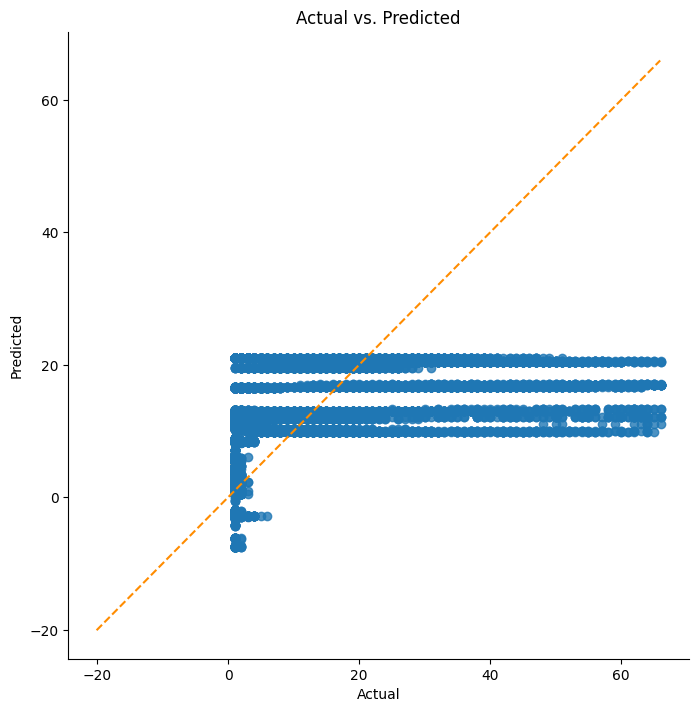

In [35]:
data = X_train
target = y_train
linear_assumptions(model, data, target)

In [36]:
corr = data.corr()
corr.style.background_gradient(cmap='coolwarm')

,date_int,item_id,price,kcal,store_id
date_int,1.000000,0.005188,-0.039520,-0.010691,-0.006012
item_id,0.005188,1.000000,-0.209976,-0.128256,0.356341
price,-0.039520,-0.209976,1.000000,0.244986,-0.162693
kcal,-0.010691,-0.128256,0.244986,1.000000,-0.287748
store_id,-0.006012,0.356341,-0.162693,-0.287748,1.000000


In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np
x = data.astype(float)  # Convert the array to float type
vif_data = pd.DataFrame()
vif_data['Features'] = x.columns
vif_data['vif'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
print(vif_data)

   Features        vif
0  date_int  14.978566
1   item_id   4.003885
2     price   3.479351
3      kcal   8.923229
4  store_id   2.729025


In [38]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [39]:
import statsmodels.api as sm
X_train = pd.DataFrame(X_train)
y_train = pd.DataFrame(y_train)
X_test = pd.DataFrame(X_test)
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')
X_train = np.asarray(X_train)
y_train = np.asarray(y_train)
X_test = np.asarray(X_test)
print(X_train.dtype)
print(y_train.dtype)
print(np.isnan(X_train).sum())
print(np.isnan(y_train).sum())
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

float64
float64
0
0
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.111
Model:                            OLS   Adj. R-squared (uncentered):              0.111
Method:                 Least Squares   F-statistic:                              400.9
Date:                Sun, 26 Apr 2026   Prob (F-statistic):                        0.00
Time:                        19:02:29   Log-Likelihood:                         -69686.
No. Observations:               16028   AIC:                                  1.394e+05
Df Residuals:                   16023   BIC:                                  1.394e+05
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

In [40]:
from sklearn import linear_model
reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)
y_pred_train = reg.predict(X_train)
y_pred_test = reg.predict(X_test)

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("R Square: {}".format(r2_score(y_train, y_pred_train)))
print("MAE: {}".format(mean_absolute_error(y_train, y_pred_train)))
print("MSE: {}".format(mean_squared_error(y_train, y_pred_train)))

R Square: 0.18068645443845277
MAE: 10.543814666267837
MSE: 198.51305881591463


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("R Square: {}".format(r2_score(y_test, y_pred_test)))
print("MAE: {}".format(mean_absolute_error(y_test, y_pred_test)))
print("MSE: {}".format(mean_squared_error(y_test, y_pred_test)))

R Square: 0.14602143977302606
MAE: 11.262596645806333
MSE: 224.36872195807788


## Random Forest

In [43]:
from sklearn.ensemble import RandomForestRegressor
yy_train = y_train.ravel()
regressor = RandomForestRegressor(n_estimators=20, random_state=0)
regressor.fit(X_train, yy_train)
y_pred_train = regressor.predict(X_train)
y_pred_test = regressor.predict(X_test)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("R Square: {}".format(r2_score(yy_train, y_pred_train)))
print("MAE: {}".format(mean_absolute_error(yy_train, y_pred_train)))
print("MSE: {}".format(mean_squared_error(yy_train, y_pred_train)))

R Square: 0.9792855718803697
MAE: 1.2112802595457948
MSE: 5.018938732218618


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("R Square: {}".format(r2_score(y_test, y_pred_test)))
print("MAE: {}".format(mean_absolute_error(y_test, y_pred_test)))
print("MSE: {}".format(mean_squared_error(y_test, y_pred_test)))

R Square: 0.6233883111922519
MAE: 5.149200581395349
MSE: 98.94848328488371


## XGBoost

### Forecast
###### Use the best-performing models to make a forecast for the next year
###### Since the Random Forest has a better R Score than Regression model, we will use the model from Random Forest to perform the forecasting

In [46]:
forecast_year = 2024
all_items = df_items.drop('name', axis=1).rename({"id": "item_id"}, axis=1)
daterange = pd.date_range(f"{forecast_year}-01-01", f"{forecast_year}-12-31")
forecast_year_date_ints = daterange.map(lambda dt: int(dt.strftime('%Y%m%d')))
X_forecast = pd.DataFrame()
n_items = all_items.shape[0]
for dt in forecast_year_date_ints:
  dts = pd.DataFrame({"date_int": np.full(n_items, dt)})
  items = pd.concat((dts, all_items), axis=1)
  X_forecast = pd.concat((X_forecast, items), axis=0)

In [47]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_forecast_scaled = sc.fit_transform(X_forecast)
y_forecast = regressor.predict(np.asarray(X_forecast_scaled))

In [48]:
X_forecast = X_forecast.merge(df_restaurants, right_on="id", left_on="store_id", left_index=False, right_index=False)
X_forecast = X_forecast.rename({"name":"store_name"}, axis=1).reset_index()

In [49]:
X_forecast["item_count"] = y_forecast
X_forecast["date"] = X_forecast["date_int"].astype("str")
X_forecast["month"] = X_forecast["date"].str[4:6]
X_forecast

,index,date_int,item_id,store_id,kcal,cost,id,store_name,name_F,item_count,date,month
0,0,20240101,1,4,554,6.71,4,Fou Cher,3,12.15,20240101,01
1,1,20240101,2,4,772,15.09,4,Fou Cher,3,1.00,20240101,01
2,2,20240101,3,1,931,29.22,1,Bob's Diner,0,1.00,20240101,01
3,3,20240101,4,1,763,26.42,1,Bob's Diner,0,1.00,20240101,01
4,4,20240101,5,5,583,6.07,5,Corner Cafe,4,12.15,20240101,01
...,...,...,...,...,...,...,...,...,...,...,...,...
36595,36595,20241231,96,5,708,21.93,5,Corner Cafe,4,1.00,20241231,12
36596,36596,20241231,97,4,744,28.65,4,Fou Cher,3,1.00,20241231,12
36597,36597,20241231,98,2,579,5.00,2,Beachfront Bar,1,16.85,20241231,12
36598,36598,20241231,99,4,423,5.32,4,Fou Cher,3,57.20,20241231,12


In [50]:
df_forecast_store_sales_by_month = X_forecast[["store_name", "month", "item_count"]].groupby(by=["store_name", "month"]).sum().reset_index()

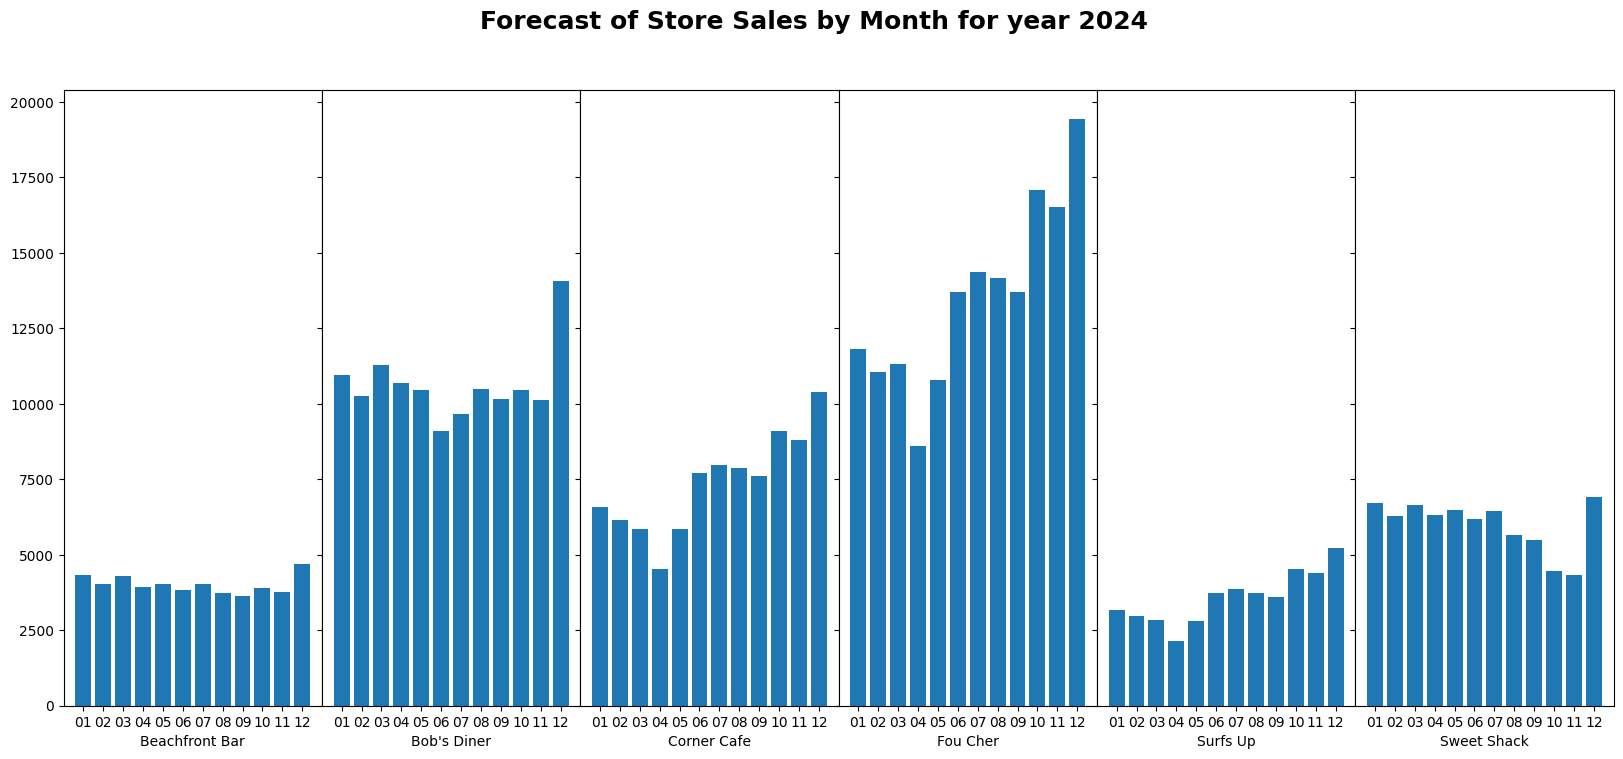

In [51]:
store_names = df_forecast_store_sales_by_month["store_name"].unique()
fig, axs = plt.subplots(1, len(store_names), sharey=True, figsize=(20,8))
for ax, store_name in zip(axs, store_names):
    df = df_forecast_store_sales_by_month[df_forecast_store_sales_by_month["store_name"] == store_name]
    ax.bar(df["month"], df["item_count"])
    ax.set_xlabel(store_name)
fig.subplots_adjust(wspace=0)
plt.suptitle(f"Forecast of Store Sales by Month for year {forecast_year}", fontsize=18, fontweight="bold")
plt.show()

# Deep Learning
###### Forecasting using deep learning algorithms

In [52]:
df_sales = df_all[["date", "sale_amount"]].groupby("date").sum()
train = df_sales[df_sales.index < '2021-07-01']
test = df_sales[df_sales.index >= '2021-07-01']

In [53]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train)
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

###### *Define the train and test series*

In [54]:
import tensorflow as tf
n_features = 1
length = 12
generator = tf.keras.preprocessing.sequence.TimeseriesGenerator(scaled_train, scaled_train, length=12, batch_size=1)

In [55]:
import tensorflow as tf
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer((length, n_features)))
model.add(tf.keras.layers.LSTM(24, return_sequences=True))
model.add(tf.keras.layers.Dropout(.5))
model.add(tf.keras.layers.LSTM(48, return_sequences=True))
model.add(tf.keras.layers.Dropout(.5))
model.add(tf.keras.layers.Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 24)         │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 48)         │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12, 1)          │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,561 (64.69 KB)

 Trainable params: 16,561 (64.69 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
validation_generator = tf.keras.preprocessing.sequence.TimeseriesGenerator(scaled_test, scaled_test, length=12, batch_size=1)

###### Build and train an LSTM model

In [57]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=.0001, patience=3, mode='auto')
model.fit(generator, epochs=20, validation_data = validation_generator, callbacks=[early_stop])

Epoch 1/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0497 - val_loss: 0.0269
Epoch 2/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0407 - val_loss: 0.0268
Epoch 3/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0395 - val_loss: 0.0262
Epoch 4/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0378 - val_loss: 0.0260
Epoch 5/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0375 - val_loss: 0.0271
Epoch 6/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0365 - val_loss: 0.0288
Epoch 7/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0360 - val_loss: 0.0256
Epoch 8/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 0.0352 - val_loss: 0.0252
Epoch 9/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0348 - val_loss: 0.0252
Epoch 10/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.0338 - val_loss: 0.0263
Epoch 11/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0332 - val_loss: 0.0279


###### Use the model to make predictions for the test data

In [59]:
test_preds = []
curr_batch = scaled_train[-length:]
for i in range(len(test)):
  curr_pred = model.predict(curr_batch)[0]
  test_preds.append(curr_pred[0])
  curr_batch = np.vstack((curr_batch[1:], curr_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━

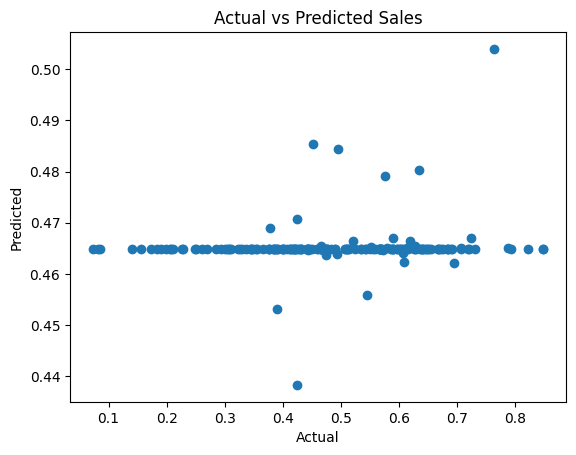

In [60]:
plt.scatter(scaled_test, test_preds)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Sales')
plt.show()

In [61]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
print("R Square: {}".format(r2_score(scaled_test, test_preds)))
print("MAPE: {}".format(mean_absolute_percentage_error(scaled_test, test_preds)))
print("MSE: {}".format(mean_squared_error(scaled_test, test_preds)))

R Square: -0.013013971577649164
MAPE: 0.36963056649190423
MSE: 0.02460266893060287


# Forecast
###### Develop another model using the entire series for training, and use it to forecast for the next three months

In [62]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(df_sales)
scaled_train = scaler.transform(df_sales)

In [63]:
import tensorflow as tf
n_features = 1
length = 12
generator = tf.keras.preprocessing.sequence.TimeseriesGenerator(scaled_train, scaled_train, length=12, batch_size=1)

In [64]:
import tensorflow as tf
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer((length, n_features)))
model.add(tf.keras.layers.LSTM(24, return_sequences=True))
model.add(tf.keras.layers.Dropout(.5))
model.add(tf.keras.layers.LSTM(48, return_sequences=True))
model.add(tf.keras.layers.Dropout(.5))
model.add(tf.keras.layers.Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 24)         │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 12, 48)         │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12, 1)          │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,561 (64.69 KB)

 Trainable params: 16,561 (64.69 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=.0001, patience=3, mode='auto')
model.fit(generator, epochs=20, callbacks=[early_stop])

Epoch 1/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0490
Epoch 2/20
  25/1084 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0336

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


1084/1084 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0381
Epoch 3/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0363
Epoch 4/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0352
Epoch 5/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0345
Epoch 6/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0336
Epoch 7/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0330
Epoch 8/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0320
Epoch 9/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0308
Epoch 10/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0297
Epoch 11/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.0282
Epoch 12/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0276
Epoch 13/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0272
Epoch 14/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0267
Epoch 15/20
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0261
Epoch 16/20
1084/1084 ━━

In [67]:
daterange = pd.date_range(f"2022-01-01", f"2022-03-31")
df_forecast = pd.DataFrame({"date": daterange, "sale_amount": [0.0] * daterange.size})
df_forecast.set_index(['date'], inplace=True)
scaled_dts = scaler.transform(df_forecast)

In [70]:
forecast_preds = []
curr_batch = scaled_dts[-length:]
for i in range(len(scaled_dts)):
  curr_pred = model.predict(curr_batch)[0]
  forecast_preds.append(curr_pred[0])
  curr_batch = np.vstack((curr_batch[1:], curr_pred))
forecast_preds = scaler.inverse_transform(forecast_preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━

In [71]:
df_forecast["sale_amount"] = forecast_preds.ravel()
df_forecast["month"] = df_forecast.index.month
df_forecast_by_month = df_forecast.groupby("month").sum()

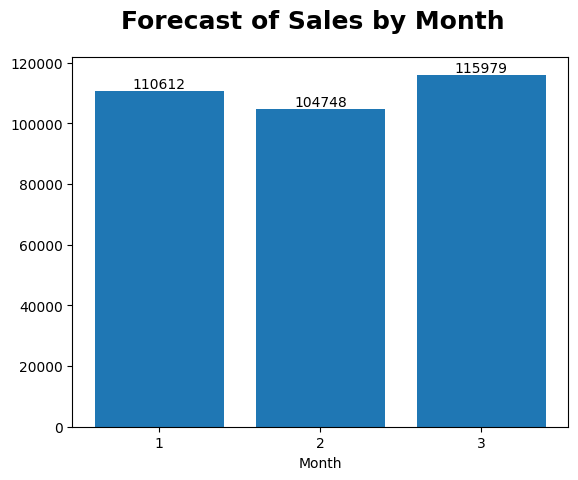

In [72]:
bar = plt.bar(df_forecast_by_month.index, df_forecast_by_month["sale_amount"])
plt.bar_label(bar, label_type='edge')
plt.xticks(df_forecast_by_month.index)
plt.xlabel("Month")
plt.suptitle(f"Forecast of Sales by Month", fontsize=18, fontweight="bold")
plt.show()

In [73]:
# Thank You